# Sachs Real-Data — Shapley Results Analysis

Mirrors `shapley_results_analysis.ipynb` but for the **Sachs cell-signalling dataset**.
Loads SHAP values, adjacency matrices, and preprocessed data that were saved by the
`real_data_exploration.ipynb` → *Save Results to Disk* cell.

**Sections**
1. Config & Imports
2. Load Shapley Values
3. Mean |SHAP| & Helper Setup
4. Global Feature Importance Comparison
5. Instance-Level Configuration
6. Causal Graph Structure: PC vs LiNGAM
7. Causal Neighbourhood: PC | True | LiNGAM *(focused ego-network — all three graphs)*
    - 7.1. SHAP Attribution Comparison: PC vs LiNGAM
8. True DAG Node Highlight *(merged into Section 7)*
9. Graph Sensitivity Analysis
    - 9.1. Data Check
    - 9.2. Graph Sensitivity Score (GSS)
    - 9.3. Sign Stability Score (SSS)
10. True-Graph Alignment (TGA)
    - 10.1. Sign Alignment vs True Graph
    - 10.2. Magnitude TGA vs True Graph
    - 10.3. Sign Alignment vs Traditional Baseline
    - 10.4. Magnitude TGA vs Traditional Baseline
11. Edge Recovery — PC & LiNGAM vs True DAG
12. Adjacency Matrix Comparison
13. Feature Importance Export


## 1. Config & Imports

In [1]:
import sys
from pathlib import Path as _Path
sys.path.insert(0, str(_Path('..').resolve()))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, collections
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import importlib
import analysis_utils
importlib.reload(analysis_utils)

from analysis_utils import (
    compute_sign_alignment, compute_tga,
    compute_sss, compute_gss,
    edge_recovery, flow_graph_stats,
    build_dag_graph, make_dag_pos, PROX_PALETTE,
    plot_shap_scatter_pc_vs_lingam, plot_instance_shap_pc_vs_lingam,
    compute_node_accuracy, get_node_accuracy,
    # ── stand-alone plot functions ──────────────────────────────────────────
    plot_feature_importance_bar,
    plot_dag_comparison,
    plot_true_dag,
    plot_dag_highlight,
    plot_dag_highlight_true,
    plot_node_neighborhood,
    plot_gss_heatmap,
    plot_gss_delta_box,
    plot_sss_heatmap,
    plot_sss_bar,
    plot_sign_alignment_heatmap,
    plot_sign_alignment_bar,
    plot_tga_heatmap,
    plot_tga_bar,
    plot_adjacency_comparison,
    plot_shap_vs_feature,
    plot_shap_vs_instance,
)

# ── Dataset / paths ───────────────────────────────────────────────────────────
DATASET = 'sachs'
MODEL   = 'lgbm'

# Show all features (only 10 proteins)
N_TOP_FEATURES = 10

BASE_DIR           = Path('..').resolve()
EXPLAINABILITY_DIR = BASE_DIR / 'data' / 'explainability'
CAUSAL_DIR         = BASE_DIR / 'data' / 'causal'
PROCESSED_DIR      = BASE_DIR / 'data' / 'processed'
SYNTHETIC_DIR      = BASE_DIR / 'data' / 'synthetic'

# ── Plots output folder ───────────────────────────────────────────────────────
PLOTS_DIR = Path('plots') / DATASET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Plots will be saved to: {PLOTS_DIR.resolve()}')

# ── Consistent colour scheme ──────────────────────────────────────────────────
METHOD_COLORS = {
    'Scratch':     '#636363',
    'Asymmetric':  '#2166ac',
    'Causal':      '#4dac26',
    'ShapleyFlow': '#d01c8b',
}

# ── Global method / graph lists used across sections 9–11 ────────────────────
BASE_METHODS = ['Asymmetric', 'Causal', 'Flow']
DISC_GRAPHS  = ['PC', 'LiNGAM']

print(f'Dataset : {DATASET}')
print(f'Model   : {MODEL}')
print(f'Top N   : {N_TOP_FEATURES}')


Plots will be saved to: /Users/juanrios/Documents/master_thesis/notebooks/plots/sachs
Dataset : sachs
Model   : lgbm
Top N   : 10


## 2. Load Shapley Values

In [2]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

METHOD_PATHS = {
    'Scratch':               exp_dir / 'scratch'  / 'shapley_values.npy',
    'Asymmetric (PC)':       exp_dir / 'pc'       / 'asymmetric' / 'shapley_values.npy',
    'Causal (PC)':           exp_dir / 'pc'       / 'causal'     / 'shapley_values.npy',
    'Flow (PC)':             exp_dir / 'pc'       / 'flow'       / 'shapley_values.npy',
    'Asymmetric (LiNGAM)':  exp_dir / 'lingam'   / 'asymmetric' / 'shapley_values.npy',
    'Causal (LiNGAM)':      exp_dir / 'lingam'   / 'causal'     / 'shapley_values.npy',
    'Flow (LiNGAM)':        exp_dir / 'lingam'   / 'flow'       / 'shapley_values.npy',
    "Asymmetric (True)": exp_dir / "true" / "asymmetric" / "shapley_values.npy",
    "Causal (True)":     exp_dir / "true" / "causal"     / "shapley_values.npy",
    "Flow (True)":       exp_dir / "true" / "flow"       / "shapley_values.npy",
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct  = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f'  {name:28s}  shape={sv.shape}  '
              f'mean|SHAP|={np.abs(sv).mean():.4f}  '
              f'NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%')
    else:
        print(f'  {name:28s}  NOT FOUND: {path}')

# ── Feature names (X only, no Y) ──────────────────────────────────────────────
with open(CAUSAL_DIR / f'{DATASET}_pc_results.json') as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f'{DATASET}_lingam_results.json') as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results['feature_names'] if n != 'Y']
n_features    = len(feature_names)

# ── Test instances ────────────────────────────────────────────────────────────
n_shap  = shap_data['Scratch'].shape[0]
test_df = pd.read_parquet(PROCESSED_DIR / f'{DATASET}_test.parquet')
x_test  = test_df[feature_names].iloc[:n_shap].values   # (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────────
pc_edges,     pc_sources     = flow_graph_stats(pc_results['adjacency_matrix'],     n_features)
lingam_edges, lingam_sources = flow_graph_stats(lingam_results['adjacency_matrix'], n_features)

print(f'\nFeatures : {n_features}    SHAP instances : {n_shap}')
print(f'PC graph     : {pc_edges} edges, {pc_sources} sources')
print(f'LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources')

  Scratch                       shape=(100, 10)  mean|SHAP|=7.7904  NaN=0.0%  zeros=0.0%
  Asymmetric (PC)               shape=(100, 10)  mean|SHAP|=8.2030  NaN=0.0%  zeros=0.0%
  Causal (PC)                   shape=(100, 10)  mean|SHAP|=9.1905  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 10)  mean|SHAP|=8.3617  NaN=0.0%  zeros=2.9%
  Asymmetric (LiNGAM)           shape=(100, 10)  mean|SHAP|=8.0255  NaN=0.0%  zeros=0.0%
  Causal (LiNGAM)               shape=(100, 10)  mean|SHAP|=9.9087  NaN=0.0%  zeros=0.0%
  Flow (LiNGAM)                 shape=(100, 10)  mean|SHAP|=7.9476  NaN=0.0%  zeros=3.6%
  Asymmetric (True)             shape=(100, 10)  mean|SHAP|=7.9857  NaN=0.0%  zeros=0.0%
  Causal (True)                 shape=(100, 10)  mean|SHAP|=9.8728  NaN=0.0%  zeros=0.0%
  Flow (True)                   shape=(100, 10)  mean|SHAP|=7.6740  NaN=0.0%  zeros=4.4%

Features : 10    SHAP instances : 100
PC graph     : 29 edges, 3 sources
LiNGAM graph : 36 edges, 1 sources


## 3. Mean |SHAP| & Helper Setup

In [3]:
# ── Mean absolute SHAP per feature ────────────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# All features ranked by Scratch importance
scratch_rank = np.argsort(mean_abs['Scratch'])[::-1][:N_TOP_FEATURES]
top_features = [feature_names[i] for i in scratch_rank]

# ── Method lists ──────────────────────────────────────────────────────────────
PC_METHODS     = ['Scratch', 'Asymmetric (PC)',     'Causal (PC)',     'Flow (PC)']
LINGAM_METHODS = ['Scratch', 'Asymmetric (LiNGAM)', 'Causal (LiNGAM)', 'Flow (LiNGAM)']

print('Mean |SHAP| per method (all features):')
for name, ma in mean_abs.items():
    print(f'  {name:28s}  {ma.mean():.4f}')

Mean |SHAP| per method (all features):
  Scratch                       7.7904
  Asymmetric (PC)               8.2030
  Causal (PC)                   9.1905
  Flow (PC)                     8.3617
  Asymmetric (LiNGAM)           8.0255
  Causal (LiNGAM)               9.9087
  Flow (LiNGAM)                 7.9476
  Asymmetric (True)             7.9857
  Causal (True)                 9.8728
  Flow (True)                   7.6740


## 4. Compute All Metrics (Centralized)

Compute all metrics once using standard functions from `analysis_utils.py`:
- **GSS** (Graph Sensitivity Score) — PC vs LiNGAM magnitude bias
- **SSS** (Sign Stability Score) — PC vs LiNGAM sign agreement
- **Sign Alignment vs True** — fraction where sign matches True graph
- **TGA vs True** — magnitude deviation from True graph
- **Sign Alignment vs Scratch** — fraction where sign matches Traditional baseline
- **TGA vs Scratch** — magnitude deviation from Traditional baseline

All visualizations and summaries later in the notebook use these pre-computed variables.

In [4]:

# ── Load True-graph SHAP for alignment metrics ────────────────────────────────
TRUE_KEYS = {
    "Asymmetric (True)": exp_dir / "true" / "asymmetric" / "shapley_values.npy",
    "Causal (True)":     exp_dir / "true" / "causal"     / "shapley_values.npy",
    "Flow (True)":       exp_dir / "true" / "flow"       / "shapley_values.npy",
}

subset_shap_data = {}
for name, path in {**METHOD_PATHS, **TRUE_KEYS}.items():
    if path.exists() and name != "Scratch":
        subset_shap_data[name] = np.load(path)

print(f"Loaded {len(subset_shap_data)} keys for alignment metrics (including True graph)")

# ── Model prediction std (normalises TGA and GSS) ────────────────────────────
import joblib as _joblib
_output_std = None
_model_path = BASE_DIR / "models" / f"{DATASET}_{MODEL}.pkl"
_test_path  = PROCESSED_DIR / f"{DATASET}_test.parquet"
if _model_path.exists() and _test_path.exists():
    _model_data = _joblib.load(_model_path)
    _lgbm       = _model_data["model"]
    _sel_feat   = _model_data.get("selected_features")
    _df_test    = pd.read_parquet(_test_path)
    _X          = _df_test.drop(columns=["Y"], errors="ignore")
    if _sel_feat is not None:
        _X = _X[_sel_feat]
    _preds = _lgbm.predict(_X)
    _output_std = float(_preds.std())
    print(f"Model prediction std: {_output_std:.4f}")
else:
    print("⚠️  Model / test file not found — TGA and GSS will not be normalised")

# ── GSS: Graph Sensitivity Score (PC vs LiNGAM magnitude bias) ────────────────
# Returns per-feature arrays: dict[method] -> ndarray(n_features,)
gss_feat = compute_gss(shap_data, BASE_METHODS, output_std=_output_std)

# Per-instance deltas (un-averaged) for box plots
feat_delta = {
    meth: np.abs(shap_data[f"{meth} (PC)"]) - np.abs(shap_data[f"{meth} (LiNGAM)"])
    for meth in BASE_METHODS
    if f"{meth} (PC)" in shap_data and f"{meth} (LiNGAM)" in shap_data
}

# ── SSS: Sign Stability Score (PC vs LiNGAM sign agreement) ───────────────────
# Returns per-feature arrays: dict[method] -> ndarray(n_features,)
sss_feat = compute_sss(shap_data, BASE_METHODS)

# ── Sign Alignment vs True DAG ─────────────────────────────────────────────────
# Returns per-feature arrays: dict[(method, graph)] -> ndarray(n_features,)
DISC_GRAPHS_TGA = ["PC", "LiNGAM"]

sign_align = compute_sign_alignment(subset_shap_data, BASE_METHODS, DISC_GRAPHS_TGA, reference="True")

# ── Magnitude TGA vs True DAG ──────────────────────────────────────────────────
# Returns per-feature arrays: dict[(method, graph)] -> ndarray(n_features,)
tga_data, _zero_feat_sets = compute_tga(
    subset_shap_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA,
    reference="True", output_std=_output_std,
)

# ── Sign Alignment vs Scratch (Traditional baseline) ──────────────────────────
# Merge subset SHAP + Scratch as reference
combined_scratch = dict(subset_shap_data)
if "Scratch" in shap_data:
    combined_scratch["Scratch"] = shap_data["Scratch"]

DISC_GRAPHS_SCRATCH = ["PC", "LiNGAM"]

sign_align_scratch = compute_sign_alignment(
    combined_scratch, BASE_METHODS, DISC_GRAPHS_SCRATCH, reference="Scratch"
)

# ── Magnitude TGA vs Scratch (Traditional baseline) ───────────────────────────
tga_data_scratch, zero_feat_sets_scratch = compute_tga(
    combined_scratch, feature_names, BASE_METHODS, DISC_GRAPHS_SCRATCH,
    reference="Scratch", output_std=_output_std,
)

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\nMetrics computed:")
print(f"  GSS: {len(gss_feat)} methods (per-feature arrays)")
print(f"  SSS: {len(sss_feat)} methods (per-feature arrays)")
print(f"  Sign Alignment vs True: {len(sign_align)} (method, graph) pairs")
print(f"  TGA vs True: {len(tga_data)} (method, graph) pairs")
print(f"  Sign Alignment vs Scratch: {len(sign_align_scratch)} (method, graph) pairs")
print(f"  TGA vs Scratch: {len(tga_data_scratch)} (method, graph) pairs")


Loaded 9 keys for alignment metrics (including True graph)
Model prediction std: 116.7861

Metrics computed:
  GSS: 3 methods (per-feature arrays)
  SSS: 3 methods (per-feature arrays)
  Sign Alignment vs True: 6 (method, graph) pairs
  TGA vs True: 6 (method, graph) pairs
  Sign Alignment vs Scratch: 6 (method, graph) pairs
  TGA vs Scratch: 6 (method, graph) pairs


## 4. Global Feature Importance Comparison

In [5]:
# fig_imp = plot_feature_importance_bar(
#     shap_data, feature_names, scratch_rank, top_features, mean_abs,
#     pc_edges, pc_sources, lingam_edges, lingam_sources,
#     METHOD_COLORS, DATASET, N_TOP_FEATURES,
#     save_dir=PLOTS_DIR,
# )

## 5. Instance-Level Configuration

Select a fixed set of test instances for per-instance SHAP visualisations (Sections 7 and 8). Using a fixed random seed ensures reproducibility.

In [6]:
N_INSTANCES = 10
_rng = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f'Selected {N_INSTANCES} instances (seed=42): {instance_idx}')

Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


## 6. Causal Graph Structure: PC vs LiNGAM

Visualise the two discovered DAGs side-by-side.
Nodes are coloured by **BFS distance from Y** (sink).

In [7]:
import networkx as nx
import matplotlib.patches as mpatches

# ── Load adjacency matrices ───────────────────────────────────────────────────
true_adj   = np.load(CAUSAL_DIR / f'{DATASET}_true_full_adjacency.npy')
pc_adj     = np.array(pc_results['adjacency_matrix'])
lingam_adj = np.array(lingam_results['adjacency_matrix'])

true_names   = pc_results['feature_names']
pc_names     = pc_results['feature_names']
lingam_names = lingam_results['feature_names']

# ── Build graphs ──────────────────────────────────────────────────────────────
G_true,   td_true,   lvg_true,   src_true,   y_true,   ml_true   = build_dag_graph(true_adj,   true_names)
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

# pos_true   = make_dag_pos(lvg_true,   ml_true)
# pos_pc     = make_dag_pos(lvg_pc,     ml_pc)
# pos_lingam = make_dag_pos(lvg_lingam, ml_lingam)

# # ── 2-panel figure: PC | LiNGAM ──────────────────────────────────────────────
# fig_dags = plot_dag_comparison(
#     G_pc, pos_pc, td_pc, src_pc, y_pc, ml_pc,
#     G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
#     DATASET, PROX_PALETTE, save_dir=PLOTS_DIR,
# )

# ── Comparison table: True | PC | LiNGAM ─────────────────────────────────────
rows_table = {}
for label, G, td, src, y_i, ml in [
    ('True',   G_true,   td_true,   src_true,   y_true,   ml_true),
    ('PC',     G_pc,     td_pc,     src_pc,     y_pc,     ml_pc),
    ('LiNGAM', G_lingam, td_lingam, src_lingam, y_lingam, ml_lingam),
]:
    rows_table[label] = {
        'nodes':      G.number_of_nodes(),
        'edges':      G.number_of_edges(),
        'direct_y':   sum(1 for u, v in G.edges() if v == y_i),
        'sources':    len(src),
        'max_depth':  ml,
        'depth_dist': collections.Counter(v for k, v in td.items() if k != y_i),
    }

def _fmt(d, key): return f'{d[key]:>10}'

print(f"\n{'Metric':<32} {'True':>10} {'PC':>10} {'LiNGAM':>10}")
print('─' * 64)
for metric in ['nodes', 'edges', 'direct_y', 'sources', 'max_depth']:
    labels_map = {'nodes': 'Total nodes', 'edges': 'Total edges', 'direct_y': 'Direct Y-parents',
                  'sources': 'Source nodes (depth 0)', 'max_depth': 'Max topo depth'}
    print(f"  {labels_map[metric]:<30}" + ''.join(_fmt(rows_table[m], metric) for m in ['True','PC','LiNGAM']))
max_d_all = max(rows_table[m]['max_depth'] for m in rows_table)
for d in range(max_d_all + 1):
    note = ' (closest to Y)' if d == max_d_all else ''
    vals = ''.join(f"{rows_table[m]['depth_dist'].get(d, 0):>10}" for m in ['True','PC','LiNGAM'])
    print(f"  {'Nodes at depth ' + str(d) + note:<30}" + vals)

# ── Edge recovery metrics ─────────────────────────────────────────────────────
pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_adj, pc_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_adj, lingam_adj)

print(f"\n{'Edge Recovery vs true_full_adj':<32} {'PC':>10} {'LiNGAM':>10}")
print('─' * 54)
print(f"  {'Precision':<30} {pc_prec:>10.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<30} {pc_rec:>10.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<30} {pc_f1:>10.3f} {lingam_f1:>10.3f}")

# ── X-only adjacency blocks & node accuracy ───────────────────────────────────
true_adj_xx         = true_adj[:n_features, :n_features]
pc_train_adj_xx     = np.load(CAUSAL_DIR / f'{DATASET}_pc_train_adjacency.npy')
lingam_train_adj_xx = np.load(CAUSAL_DIR / f'{DATASET}_lingam_train_adjacency.npy')

node_acc_pc     = compute_node_accuracy(true_adj_xx, pc_train_adj_xx,     feature_names)
node_acc_lingam = compute_node_accuracy(true_adj_xx, lingam_train_adj_xx, feature_names)



Metric                                 True         PC     LiNGAM
────────────────────────────────────────────────────────────────
  Total nodes                           11        11        11
  Total edges                           27        29        36
  Direct Y-parents                      10        10        10
  Source nodes (depth 0)                 1         3         1
  Max topo depth                         7         6         8
  Nodes at depth 0                       1         3         1
  Nodes at depth 1                       1         2         2
  Nodes at depth 2                       1         1         1
  Nodes at depth 3                       1         1         1
  Nodes at depth 4                       1         1         1
  Nodes at depth 5                       3         1         1
  Nodes at depth 6                       1         1         1
  Nodes at depth 7                       1         0         1
  Nodes at depth 8 (closest to Y)         0      

### 6.1. True Causal Graph

Ground-truth DAG (Sachs 2005) for comparison against the discovered PC and LiNGAM graphs above.

In [8]:
# fig_true = plot_true_dag(
#     G_true, pos_true, td_true, src_true, y_true, ml_true,
#     DATASET, PROX_PALETTE, save_dir=PLOTS_DIR,
# )


## 7. Causal Neighbourhood: PC | True | LiNGAM

Focused view of one protein's direct neighbourhood across all three graphs.
Unlike the full-graph highlight, this panel shows **only** the focal node, its
direct parents (incoming causal drivers) and direct children (outgoing targets) —
nothing else. Designed for qualitative comparison in the thesis.

| Colour | Meaning |
|--------|---------|
| Dark slate | Focal node (subject) |
| Light blue | Parents — nodes that *cause* the focal feature |
| Light peach | Children — nodes that the focal feature *causes* |
| Light pink | Y — prediction target |

Panel title colour identifies the graph: **sky-blue** = PC, **dark** = True DAG, **orange** = LiNGAM.
Change `HIGHLIGHT_FEATURE` to any protein name to inspect a different node.


  ✅  Saved → plots/sachs/dag_neighborhood_erk_sachs.png


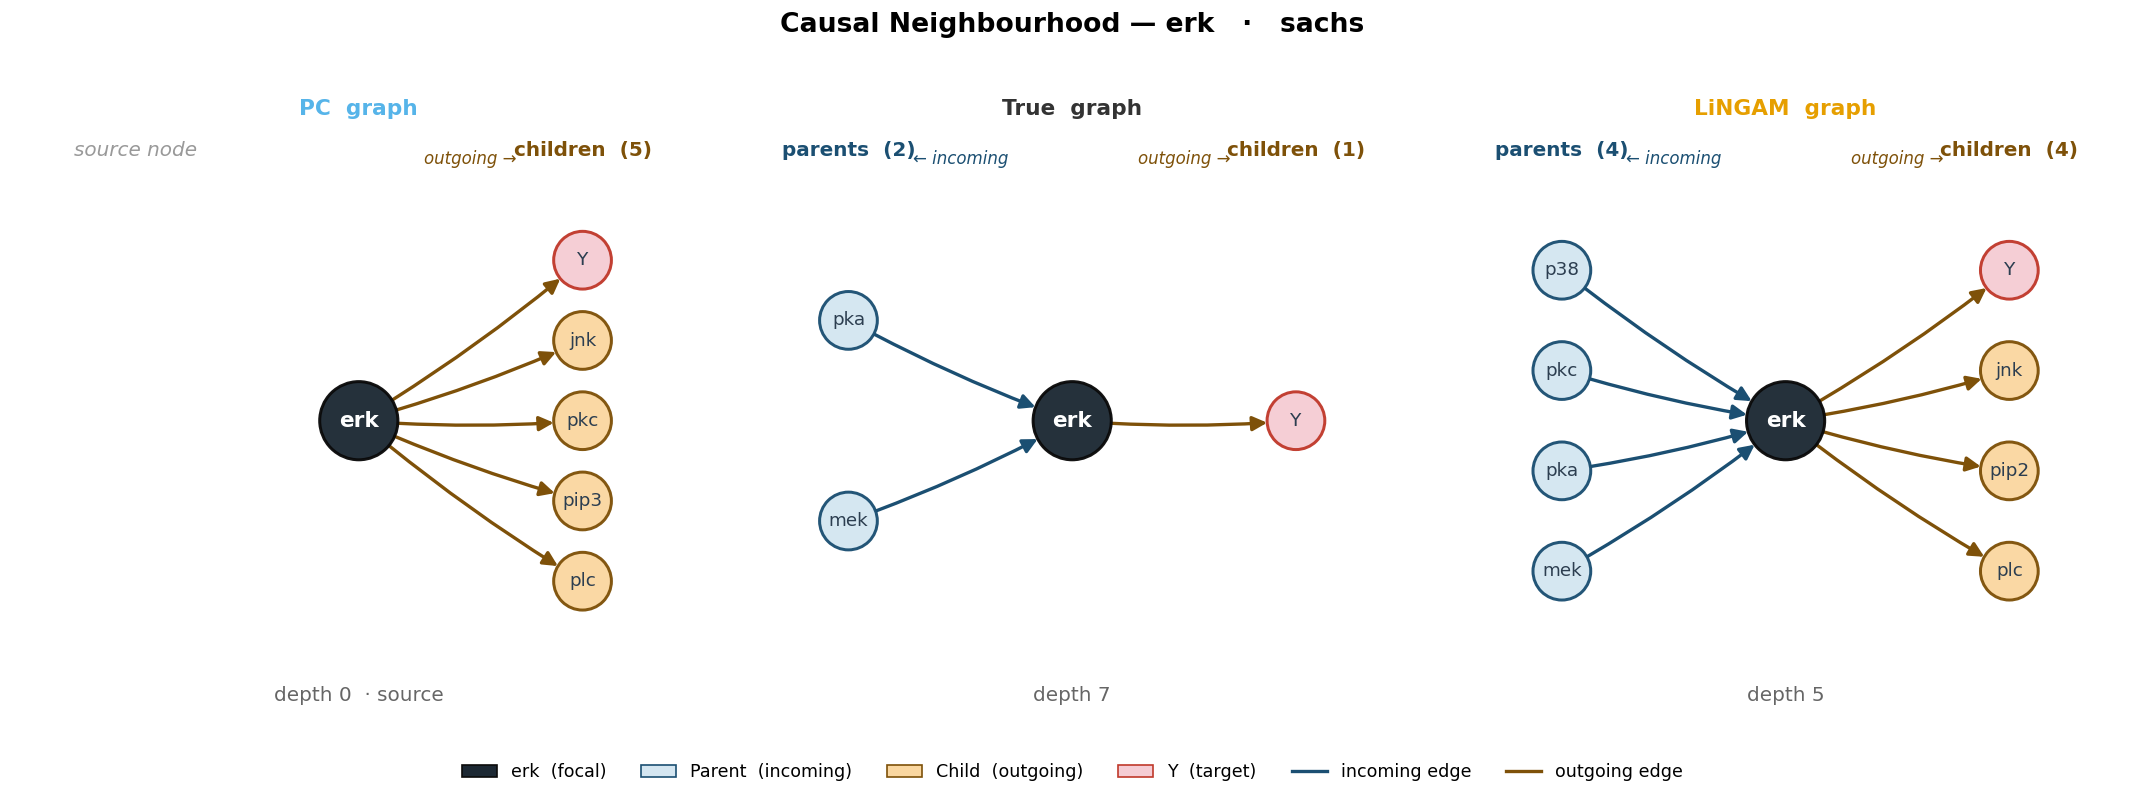

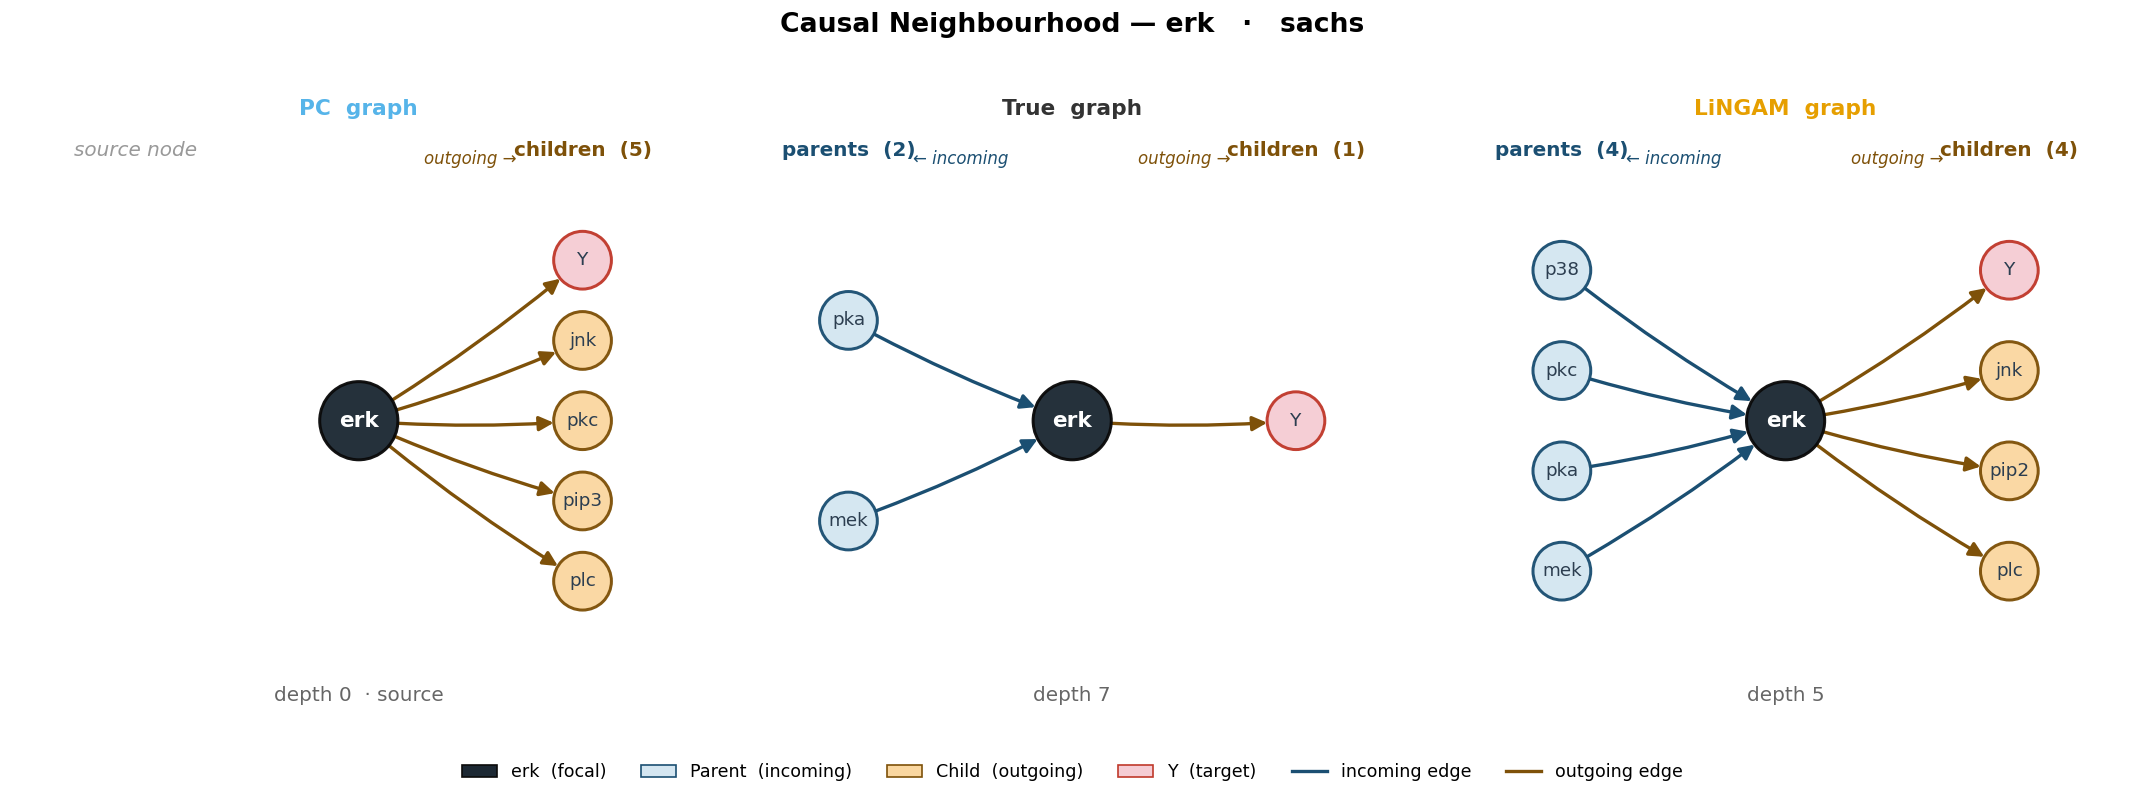

In [9]:
HIGHLIGHT_FEATURE = 'erk'   # change to any protein name

plot_node_neighborhood(
    HIGHLIGHT_FEATURE,
    G_pc,     td_pc,     src_pc,     y_pc,     pc_names,
    G_true,   td_true,   src_true,   y_true,   true_names,
    G_lingam, td_lingam, src_lingam, y_lingam, lingam_names,
    DATASET, save_dir=PLOTS_DIR,
)


### 7.1. SHAP Attribution Comparison: PC vs LiNGAM

For a single test instance, compare how each causal SHAP method attributes feature contributions when using the PC-discovered graph versus the LiNGAM-discovered graph.

In [10]:
HIGHLIGHT_FEATURES = [HIGHLIGHT_FEATURE]   # features to inspect in section 7.1


In [11]:
fig_scatter = plot_shap_scatter_pc_vs_lingam(
    shap_data, feature_names, scratch_rank, top_features, x_test,
    pc_edges, lingam_edges, DATASET, N_TOP_FEATURES,
    method = "Flow",
    features=HIGHLIGHT_FEATURES,
    save_dir=PLOTS_DIR,
)

  ✅  Saved → plots/sachs/shap_scatter_flow_erk_sachs.png


In [12]:
# ── Node-level causal accuracy for the highlighted feature ────────────────────
get_node_accuracy(
    HIGHLIGHT_FEATURES,
    {'PC': node_acc_pc, 'LiNGAM': node_acc_lingam},
)


 graph feature  in_prec  in_rec  in_f1  out_prec  out_rec  out_f1  overall_prec  overall_rec  overall_f1
LiNGAM     erk    0.500   1.000  0.667     0.000      NaN     NaN         0.286        1.000       0.444
    PC     erk      NaN   0.000    NaN     0.000      NaN     NaN         0.000        0.000       0.000


,graph,feature,in_prec,in_rec,in_f1,out_prec,out_rec,out_f1,overall_prec,overall_rec,overall_f1,true_in,pred_in,true_out,pred_out
0,LiNGAM,erk,0.5,1.0,0.666667,0.0,NaN,NaN,0.285714,1.0,0.444444,2,4,0,3
1,PC,erk,NaN,0.0,NaN,0.0,NaN,NaN,0.000000,0.0,0.000000,2,0,0,4


In [13]:
baseline = 'Flow (True)'
compared = 'Asymmetric (PC)'

# SHAP vs Feature Value
plot_shap_vs_feature(
    shap_data, feature_names, x_test,
    method_1=baseline,
    method_2=compared,
    features=HIGHLIGHT_FEATURES,
    dataset=DATASET,
    save_dir=PLOTS_DIR,
)

# SHAP vs Instance
plot_shap_vs_instance(
    shap_data, feature_names,
    method_1=baseline,
    method_2=compared,
    features=HIGHLIGHT_FEATURES,
    # instance_idx=instance_idx,   # optional — None = all instances
    dataset=DATASET,
    mode='markers',              # or "lines+markers"
    save_dir=PLOTS_DIR,
)


  ✅  Saved → plots/sachs/shap_vs_feature_Flow__True__vs_Asymmetric__PC__sachs.png


  ✅  Saved → plots/sachs/shap_vs_instance_Flow__True__vs_Asymmetric__PC__sachs.png


## 8. True DAG Node Highlight

> The True-graph neighbourhood is now shown as the **centre panel** of the Section 7 figure (`plot_node_neighborhood`).  
> This section is kept as a placeholder for any additional True-graph analysis.


In [14]:
# True-graph neighbourhood is now the centre panel of plot_node_neighborhood (Section 7).
# Uncomment to draw the True DAG standalone if needed:
# fig_highlight_true = plot_dag_highlight_true(
#     G_true, pos_true, td_true, src_true, y_true, ml_true,
#     HIGHLIGHT_FEATURE, true_names, DATASET,
#     save_dir=PLOTS_DIR,
# )


## 9. Graph Sensitivity Analysis

Compare how much the choice of causal graph (PC vs LiNGAM) affects the SHAP attributions.
Two complementary metrics are used: **GSS** (magnitude gap) and **SSS** (sign stability).

### 9.1. Data Check

All data (SHAP values, adjacency matrices, model std) was loaded centrally in **Sections 2 & 4**. Run the cell below to confirm everything is in scope.


In [15]:
# All data for sections 9–12 was loaded centrally in Sections 2 & 4.
# No re-loading needed — run those sections first if the kernel was restarted.
N_TRUE_INSTANCES = subset_shap_data.get('Asymmetric (True)', np.zeros((0, 1))).shape[0]
print('✅  Data loaded centrally — ready for sections 9–12.')
print(f'    Methods: {list(subset_shap_data.keys())}')
print(f'    Features: {len(feature_names)}  |  True-graph instances: {N_TRUE_INSTANCES}')


✅  Data loaded centrally — ready for sections 9–12.
    Methods: ['Asymmetric (PC)', 'Causal (PC)', 'Flow (PC)', 'Asymmetric (LiNGAM)', 'Causal (LiNGAM)', 'Flow (LiNGAM)', 'Asymmetric (True)', 'Causal (True)', 'Flow (True)']
    Features: 10  |  True-graph instances: 100


### 9.2. Graph Sensitivity Score (GSS)

$$\text{GSS}(m,f) = \text{mean}_i\bigl(|\varphi^{(m,\text{PC})}_{i,f}| - |\varphi^{(m,\text{LiNGAM})}_{i,f}|\bigr)$$

Signed: **positive** = PC assigns higher importance; **negative** = LiNGAM assigns higher; **≈0** = both agree.

In [ ]:
# ── Use pre-computed GSS from section 4 ──────────────────────────────────────
# All GSS values were already computed by compute_gss() in section 4
# gss_feat is a dict[method] -> ndarray(n_features,) containing per-feature GSS

for label in BASE_METHODS:
    if label not in gss_feat:
        continue
    g = gss_feat[label]
    print(f'{label}: mean GSS = {np.mean(g):.4f}  min = {np.min(g):.4f}  max = {np.max(g):.4f}')

# ── Visualizations ────────────────────────────────────────────────────────────
fig_gss = plot_gss_heatmap(
    gss_feat, feature_names, BASE_METHODS, DATASET,
    save_dir=PLOTS_DIR,
)



fig_delta = plot_gss_delta_box(
    feat_delta, feature_names, METHOD_COLORS, DATASET, N_TOP_FEATURES,
    save_dir=PLOTS_DIR,
)

Asymmetric: mean GSS = 0.0846  min = 0.0040  max = 0.3580
Causal: mean GSS = 0.1011  min = 0.0097  max = 0.2601
Flow: mean GSS = 0.1492  min = 0.0054  max = 0.5754


  ✅  Saved → plots/sachs/gss_heatmap_sachs.png


### 9.4. Sign Stability Score (SSS)

$$\text{SSS}(m,f) = \frac{1}{n}\sum_i \mathbf{1}\!\left[\text{sign}(\varphi^{(m,\text{PC})}_{i,f}) = \text{sign}(\varphi^{(m,\text{LiNGAM})}_{i,f})\right]$$

1 = sign always the same under PC and LiNGAM; 0 = always flips.

**Note:** Metrics already computed in section 4. Using pre-computed `sss_feat`.

In [ ]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sss_feat

for meth, arr in sss_feat.items():
    print(f'{meth}: mean SSS = {np.nanmean(arr):.4f}  '
          f'min SSS = {np.nanmin(arr):.4f}  '
          f'features with SSS<0.5 = {(arr < 0.5).sum()}')

fig_sss = plot_sss_heatmap(
    sss_feat, feature_names, BASE_METHODS, DATASET,
    save_dir=PLOTS_DIR,
)

fig_sss_bar = plot_sss_bar(
    sss_feat, BASE_METHODS, METHOD_COLORS, DATASET,
    save_dir=PLOTS_DIR,
)

Asymmetric: mean SSS = 0.8140  min SSS = 0.5700  features with SSS<0.5 = 0
Causal: mean SSS = 0.6820  min SSS = 0.3400  features with SSS<0.5 = 2
Flow: mean SSS = 0.7812  min SSS = 0.4948  features with SSS<0.5 = 1


  ✅  Saved → plots/sachs/sss_heatmap_sachs.png


  ✅  Saved → plots/sachs/sss_bar_sachs.png


## 10. True-Graph Alignment (TGA)

Compares SHAP attributions from PC- and LiNGAM-discovered graphs against the **ground-truth Sachs DAG** oracle.

### 10.1. Sign Alignment vs True Graph

$$\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_i \mathbf{1}\!\left[\text{sign}(\varphi^{(m,g)}_{i,f}) = \text{sign}(\varphi^{(m,\text{True})}_{i,f})\right]$$

- **1.0** — signs always agree with the True-graph attribution.
- **0.5** — random (half positive, half negative).
- **0.0** — signs always disagree.

**Note:** Metrics already computed in section 4. Using pre-computed `sign_align`.

In [ ]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sign_align

if sign_align:
    sa_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_TGA:
            if (meth, g) not in sign_align:
                continue
            arr = sign_align[(meth, g)]
            sa_rows.append(dict(
                Method=meth, Graph=g,
                MeanAlign=float(np.nanmean(arr)),
                label=f'{meth} ({g})',
            ))
    df_sa = pd.DataFrame(sa_rows)

    fig_sa_hmap = plot_sign_alignment_heatmap(
        sign_align, BASE_METHODS, DISC_GRAPHS_TGA, feature_names,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )
    fig_sa_bar = plot_sign_alignment_bar(
        df_sa, sign_align, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR,
    )
else:
    print('⚠️  No sign-alignment data computed.')

  ✅  Saved → plots/sachs/sign_alignment_heatmap_sachs.png


  ✅  Saved → plots/sachs/sign_alignment_bar_sachs.png


### 10.2. Magnitude True-Graph Alignment

$$\text{TGA}(m, g, f) = \frac{1}{n}\sum_i\left(|\varphi^{(m,g)}_{i,f}| - |\varphi^{(m,\text{True})}_{i,f}|\right)$$

- **Positive** — discovered graph over-estimates True-graph importance.
- **Negative** — discovered graph under-estimates True-graph importance.
- **≈ 0** — magnitude agrees with True-graph oracle.

**Note:** Metrics already computed in section 4. Using pre-computed `tga_data`.

In [ ]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed tga_data

if tga_data:
    tga_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_TGA:
            if (meth, g) not in tga_data:
                continue
            arr = tga_data[(meth, g)]
            tga_rows.append(dict(
                Method=meth, Graph=g,
                MeanTGA=float(np.mean(arr)),
                label=f'{meth} ({g})',
            ))
    df_tga = pd.DataFrame(tga_rows)

    fig_tga_hmap = plot_tga_heatmap(
        tga_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )
    fig_tga_bar = plot_tga_bar(df_tga, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)
else:
    print('⚠️  No TGA data computed.')

  ✅  Saved → plots/sachs/tga_heatmap_sachs.png


  ✅  Saved → plots/sachs/tga_bar_sachs.png


### 10.3. Sign Alignment vs Traditional Baseline

Compares each (method × graph) against **Traditional** (graph-free SHAP) using the same sign-alignment metric as Section 10.1.

$$\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_i \mathbf{1}\!\left[\text{sign}(\varphi^{(m,g)}_{i,f}) = \text{sign}(\varphi^{(\text{Traditional})}_{i,f})\right]$$

This measures how much the causal graph structure *changes* the attributions relative to the graph-free baseline.

**Note:** Metrics already computed in section 4. Using pre-computed `sign_align_scratch`.

In [ ]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sign_align_scratch

if sign_align_scratch:
    sa_scratch_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_SCRATCH:
            if (meth, g) not in sign_align_scratch:
                continue
            arr = sign_align_scratch[(meth, g)]
            sa_scratch_rows.append(dict(
                Method=meth, Graph=g,
                MeanAlign=float(np.nanmean(arr)),
            ))
    df_sa_scratch = pd.DataFrame(sa_scratch_rows)
    
    # ── A: Feature-level sign alignment heatmap ───────────────────────────
    sa_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_SCRATCH 
                 if (m, g) in sign_align_scratch]
    sa_labels = [f'{m} ({g})' for m, g in sa_keys]
    sa_matrix = np.stack([sign_align_scratch[k] for k in sa_keys], axis=1)
    
    # Sort features by worst mean alignment
    feat_order = np.argsort(sa_matrix.mean(axis=1))
    top_n_sa = min(40, len(feature_names))
    top_idx_sa = feat_order[:top_n_sa]
    
    fig_sign_hmap_scratch = go.Figure(go.Heatmap(
        z=sa_matrix[top_idx_sa], x=sa_labels,
        y=[feature_names[i] for i in top_idx_sa],
        colorscale='RdYlGn', zmin=0, zmax=1.0,
        colorbar=dict(
            title=dict(text='Sign Align', font=dict(size=11)),
            tickvals=[0, 0.25, 0.5, 0.75, 1.0],
            ticktext=['0 (opp.)', '0.25', '0.5', '0.75', '1.0'],
        ),
        hovertemplate='<b>%{y}</b> — %{x}<br>Sign Align = %{z:.3f}<extra></extra>',
    ))
    fig_sign_hmap_scratch.update_layout(
        title=dict(
            text=(
                f'Sign Alignment vs Traditional Baseline — {DATASET}<br>'
                f'<sup>Fraction where sign(φ_causal) = sign(φ_Traditional). '
                f'Top {top_n_sa} features by worst alignment. N={N_INSTANCES}</sup>'
            ),
            font=dict(size=13),
        ),
        height=max(420, 18 * top_n_sa + 120), width=760,
        yaxis=dict(tickfont=dict(size=9)),
        xaxis=dict(tickfont=dict(size=9), tickangle=-25),
        margin=dict(l=80, r=80, t=90, b=80),
    )
    fig_sign_hmap_scratch.show()
    
    # ── B: Overall sign alignment bar chart ───────────────────────────────
    fig_sign_bar_scratch = go.Figure()
    for g in DISC_GRAPHS_SCRATCH:
        sub = df_sa_scratch[df_sa_scratch['Graph'] == g]
        for _, row in sub.iterrows():
            fig_sign_bar_scratch.add_trace(go.Bar(
                name=row['Method'], x=[g], y=[row['MeanAlign']],
                marker_color=METHOD_COLORS.get(row['Method'], '#888888'),
                showlegend=(g == DISC_GRAPHS_SCRATCH[0]),
                hovertemplate=f"<b>{row['Method']} ({g})</b><br>Mean Align=%{{y:.3f}}<extra></extra>",
            ))
    fig_sign_bar_scratch.update_layout(
        title=dict(
            text=(
                f'Overall Sign Alignment vs Traditional — {DATASET}<br>'
                f'<sup>Mean across features. 1.0 = all signs match Traditional baseline</sup>'
            ),
            font=dict(size=13),
        ),
        barmode='group', yaxis=dict(title='Mean Sign Alignment', range=[0, 1.05]),
        height=380, width=600,
        xaxis=dict(title='Graph'),
        margin=dict(t=90, b=80),
    )
    fig_sign_bar_scratch.add_hline(
        y=0.5, line=dict(color='gray', width=1, dash='dot'),
        annotation_text='random (0.5)', annotation_font_size=9
    )
    fig_sign_bar_scratch.show()
    
    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
    print('─' * 55)
    for row in sa_scratch_rows:
        arr = sign_align_scratch[(row['Method'], row['Graph'])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")
else:
    print('⚠️  No sign-alignment data computed.')


Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.8320          0
  Asymmetric   LiNGAM             0.8300          0
  Causal       PC                 0.6870          1
  Causal       LiNGAM             0.6690          2
  Flow         PC                 0.5980          1
  Flow         LiNGAM             0.5850          1


### 10.4. Magnitude TGA vs Traditional Baseline

Same magnitude deviation metric, but comparing against **Traditional** (graph-free) instead of True-graph.

$$\text{TGA}(m, g, f) = \frac{1}{n}\sum_i\left(|\varphi^{(m,g)}_{i,f}| - |\varphi^{(\text{Traditional})}_{i,f}|\right)$$

- **Positive** — causal graph over-estimates Traditional importance.
- **Negative** — causal graph under-estimates Traditional importance.
- **≈ 0** — causal graph and Traditional agree in magnitude.

**Note:** Metrics already computed in section 4. Using pre-computed `tga_data_scratch`.

In [ ]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed tga_data_scratch

if tga_data_scratch:
    # ── Build summary data ─────────────────────────────────────────────────
    tga_scratch_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_SCRATCH:
            if (meth, g) not in tga_data_scratch:
                continue
            arr = tga_data_scratch[(meth, g)]
            tga_scratch_rows.append(dict(
                Method=meth, Graph=g,
                MeanTGA=float(np.mean(arr)),
            ))
    df_tga_scratch = pd.DataFrame(tga_scratch_rows)
    
    # ── A: Feature-level TGA heatmap ───────────────────────────────────────
    fig_tga_hmap_scratch = plot_tga_heatmap(
        tga_data_scratch, feature_names, BASE_METHODS, DISC_GRAPHS_SCRATCH,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )
    
    # ── B: Overall TGA bar chart ──────────────────────────────────────────
    fig_tga_bar_scratch = go.Figure()
    for g in DISC_GRAPHS_SCRATCH:
        sub = df_tga_scratch[df_tga_scratch['Graph'] == g]
        for _, row in sub.iterrows():
            fig_tga_bar_scratch.add_trace(go.Bar(
                name=row['Method'], x=[g], y=[row['MeanTGA']],
                marker_color=METHOD_COLORS.get(row['Method'], '#888888'),
                showlegend=(g == DISC_GRAPHS_SCRATCH[0]),
                hovertemplate=f"<b>{row['Method']} ({g})</b><br>Mean TGA=%{{y:.4f}}<extra></extra>",
            ))
    fig_tga_bar_scratch.update_layout(
        title=dict(
            text=(
                f'Overall Magnitude TGA vs Traditional — {DATASET}<br>'
                f'<sup>Higher = larger magnitude difference from Traditional baseline</sup>'
            ),
            font=dict(size=13),
        ),
        barmode='group', yaxis=dict(title='Mean TGA', range=[0, None]),
        height=380, width=600,
        xaxis=dict(title='Graph'),
        margin=dict(t=90, b=80),
    )
    fig_tga_bar_scratch.show()
    
    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  "
          f"{'Max TGA':>10}  {'TGA>0.1':>10}")
    print('─' * 72)
    for row in tga_scratch_rows:
        arr = tga_data_scratch[(row['Method'], row['Graph'])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
              f"{np.max(arr):>10.4f}  {(arr>0.1).sum():>10d}")
else:
    print('⚠️  No TGA data computed — check that combined_scratch has Scratch key.')

  ✅  Saved → plots/sachs/tga_heatmap_sachs.png



Method         Graph       Mean TGA   Median TGA     Max TGA     TGA>0.1
────────────────────────────────────────────────────────────────────────
  Asymmetric   PC            0.0508       0.0249      0.2042           2
  Asymmetric   LiNGAM        0.0441       0.0139      0.1733           2
  Causal       PC            0.0783       0.0545      0.1848           3
  Causal       LiNGAM        0.0931       0.0672      0.2173           3
  Flow         PC            0.1268       0.0766      0.5795           5
  Flow         LiNGAM        0.1413       0.1043      0.4094           5


## 11. Edge Recovery — PC & LiNGAM vs True DAG

In [ ]:
# Load train-only adjacency matrices (X-only block)
true_adj_xx         = true_adj[:n_features, :n_features]
pc_train_adj_xx     = np.load(CAUSAL_DIR / f'{DATASET}_pc_train_adjacency.npy')
lingam_train_adj_xx = np.load(CAUSAL_DIR / f'{DATASET}_lingam_train_adjacency.npy')

pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_adj, pc_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_adj, lingam_adj)

pc_prec_xx,     pc_rec_xx,     pc_f1_xx     = edge_recovery(true_adj_xx, pc_train_adj_xx)
lingam_prec_xx, lingam_rec_xx, lingam_f1_xx = edge_recovery(true_adj_xx, lingam_train_adj_xx)

print(f"{'Edge Recovery (full n+1 × n+1 adj)':<40} {'PC':>8} {'LiNGAM':>10}")
print('─' * 60)
print(f"  {'Precision':<38} {pc_prec:>8.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<38} {pc_rec:>8.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<38} {pc_f1:>8.3f} {lingam_f1:>10.3f}")

print(f"\n{'Edge Recovery (X-only train adj)':<40} {'PC':>8} {'LiNGAM':>10}")
print('─' * 60)
print(f"  {'Precision':<38} {pc_prec_xx:>8.3f} {lingam_prec_xx:>10.3f}")
print(f"  {'Recall':<38} {pc_rec_xx:>8.3f} {lingam_rec_xx:>10.3f}")
print(f"  {'F1':<38} {pc_f1_xx:>8.3f} {lingam_f1_xx:>10.3f}")

Edge Recovery (full n+1 × n+1 adj)             PC     LiNGAM
────────────────────────────────────────────────────────────
  Precision                                 0.448      0.472
  Recall                                    0.481      0.630
  F1                                        0.464      0.540

Edge Recovery (X-only train adj)               PC     LiNGAM
────────────────────────────────────────────────────────────
  Precision                                 0.158      0.269
  Recall                                    0.176      0.412
  F1                                        0.167      0.326


## 12. Adjacency Matrix Comparison

  ✅  Saved → plots/sachs/adjacency_comparison_sachs.png


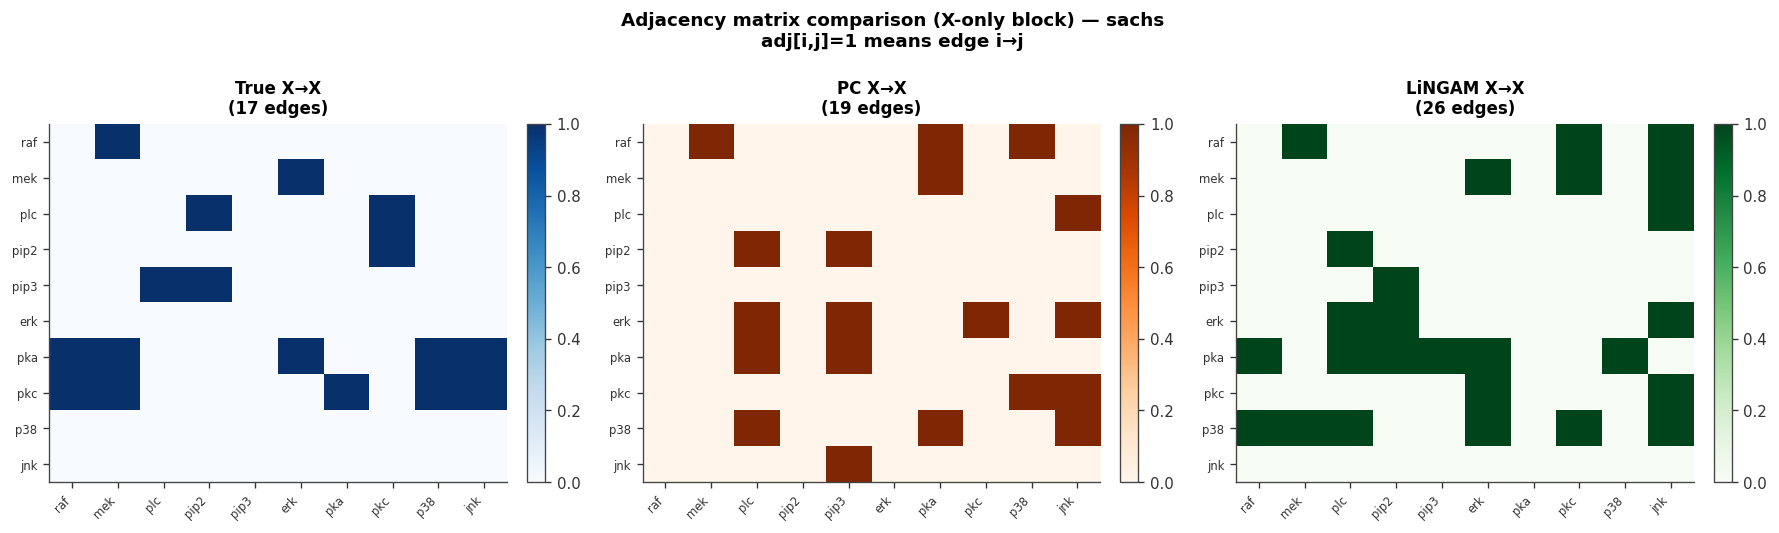

In [ ]:
fig_adj = plot_adjacency_comparison(
    true_adj_xx, pc_train_adj_xx, lingam_train_adj_xx,
    feature_names, DATASET, save_dir=PLOTS_DIR,
)

## 13. Feature Importance Export

In [ ]:
rows_fi = []
for feat_i, feat in enumerate(feature_names):
    row = {
        'feature':     feat,
    }
    for method_key, sv in shap_data.items():
        col = method_key.replace(' ', '_').replace('(', '').replace(')', '')
        row[f'{col}_mean_shap']     = float(sv.mean(axis=0)[feat_i])
        row[f'{col}_mean_abs_shap'] = float(np.abs(sv).mean(axis=0)[feat_i])
    rows_fi.append(row)

df_fi = pd.DataFrame(rows_fi).set_index('feature')

# Add rank columns
for col in [c for c in df_fi.columns if c.endswith('_mean_abs_shap')]:
    rank_col = col.replace('_mean_abs_shap', '_rank')
    df_fi[rank_col] = df_fi[col].rank(ascending=False, method='min').astype(int)

# Interleave per-method: mean_shap / mean_abs_shap / rank
abs_cols  = [c for c in df_fi.columns if c.endswith('_mean_abs_shap')]
shap_cols = [c.replace('_mean_abs_shap', '_mean_shap') for c in abs_cols]
rank_cols = [c.replace('_mean_abs_shap', '_rank')      for c in abs_cols]
ordered   = [c for trio in zip(shap_cols, abs_cols, rank_cols) for c in trio]
df_fi = df_fi[ordered].sort_values(abs_cols[0], ascending=False)

out_path = EXPLAINABILITY_DIR / DATASET / f'feature_importance_{DATASET}.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
df_fi.to_csv(out_path, sep=';', decimal=',')
print(f'Saved → {out_path}')
print(f'Shape  : {df_fi.shape}  ({n_features} features × {len(abs_cols)} methods × 3 metrics)')
df_fi

Saved → /Users/juanrios/Documents/master_thesis/data/explainability/sachs/feature_importance_sachs.csv
Shape  : (10, 30)  (10 features × 10 methods × 3 metrics)


,Scratch_mean_shap,Scratch_mean_abs_shap,Scratch_rank,Asymmetric_PC_mean_shap,Asymmetric_PC_mean_abs_shap,Asymmetric_PC_rank,Causal_PC_mean_shap,Causal_PC_mean_abs_shap,Causal_PC_rank,Flow_PC_mean_shap,...,Flow_LiNGAM_rank,Asymmetric_True_mean_shap,Asymmetric_True_mean_abs_shap,Asymmetric_True_rank,Causal_True_mean_shap,Causal_True_mean_abs_shap,Causal_True_rank,Flow_True_mean_shap,Flow_True_mean_abs_shap,Flow_True_rank
feature,,,,,,,,,,,,,,,,,,,,,
erk,-14.322513,40.431243,1,-24.581741,42.353180,1,-16.371777,45.447477,1,-7.374164,...,4,-4.237653,38.145086,1,-4.984768,38.726862,1,-3.050951,14.794082,3
pka,-4.614743,17.209088,2,-1.906667,19.562432,2,-5.350654,15.018430,2,0.971419,...,1,-8.693606,18.650519,2,-12.712223,21.686333,2,-2.388254,23.822928,1
mek,-3.179536,10.287468,3,-0.039335,9.223953,3,-1.060291,4.806293,4,-2.345408,...,3,-6.751083,12.658424,3,-0.247285,5.311402,6,-3.691663,16.206699,2
plc,-1.260307,3.680643,4,1.311440,3.212333,4,0.434120,1.947245,8,-0.016146,...,9,-2.916319,3.612737,4,-1.710711,5.834491,5,0.127998,2.097689,7
pip2,0.359340,1.199397,5,0.545850,1.067272,9,1.028581,2.820966,7,0.641879,...,8,0.561781,1.111627,8,-0.171253,4.610218,7,0.120311,0.873662,8
jnk,-0.338833,1.151696,6,-0.207835,1.535688,5,-0.129014,1.209102,10,-0.067548,...,10,-0.356323,1.602375,5,-0.217420,3.001602,9,-0.080548,0.465336,10
p38,-0.132096,1.148571,7,0.539129,1.306003,8,0.453159,2.982084,6,0.943466,...,2,-1.045407,1.536198,6,-0.023877,2.411086,10,0.147251,0.568863,9
raf,0.232167,1.056526,8,0.787881,1.317523,7,-1.884295,11.623108,3,-1.987015,...,6,-0.055304,1.263396,7,-2.126774,6.580034,4,-0.714286,2.960022,5
pkc,-0.146103,0.949944,9,0.383318,1.056374,10,-0.243926,4.695173,5,-0.197760,...,5,-0.061701,0.768609,9,-0.049049,7.527851,3,-0.004710,12.683232,4
